# Abstraction

Entity matching (EM) tries to find same real-world entities from different data sources. In this notebook, we will try to build a POC for EM of HealthCare data.

This is small dataset, it contains many sheets. We try to process data into 2 datasets then we can compare data between 2 datasets together.
after that we try to process data and apply classification in our data. The steps would be:

**Step 1**: concatenate data and build 2 dataset **A** and **B**

**Step 2**: Apply Magellan into preprocess data

**Step 3**: Building a classification model

**Step 4**: Evaluate model

# Import library

In [ ]:
!pip install  torchtext==0.10.0  torch==1.9

In [1]:
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from itertools import permutations
import os 
import typing

try:
  import msoffcrypto
  import py_entitymatching as em
except:
  !pip install msoffcrypto-tool
finally:
  import msoffcrypto

try:
    import py_entitymatching as em
except:
    !pip install setuptools wheel
    !pip install Cython
    !pip install git+https://github.com/anhaidgroup/py_stringsimjoin.git@master
    !pip install git+https://github.com/anhaidgroup/py_entitymatching.git@master
    !pip install fasttext-wheel
finally:
  import py_entitymatching as em

import sys
sys.path.append('/Users/tu/SourceCode/GRIT/deepmatcher')
import deepmatcher as dm

pd.options.display.max_columns = None
# import logging
# logger = logging.getLogger()
# logger.setLevel(logging.DEBUG)
# logging.debug("test")

In [2]:
alameda_dir = 'alameda/'

# Data Loading

In [3]:
passwd = 'your_password'
decrypted_workbook = io.BytesIO()
with open(alameda_dir + "hcp-manz-sn.xlsx", 'rb') as file:
    office_file = msoffcrypto.OfficeFile(file)
    office_file.load_key(password=passwd)
    office_file.decrypt(decrypted_workbook)

df_dict = {}
for sheet_name in pd.read_excel(decrypted_workbook, None).keys():
  df = pd.read_excel(decrypted_workbook, sheet_name=sheet_name)
  df_dict[sheet_name] = df

# Data Exploration and Understanding

### Building pair of datasets

In [4]:
B = []
for key in df_dict.keys():
  if key == '(1000) Contacts':
    A = df_dict[key]
    continue
  if key!='(360) Validation Check':
    df = df_dict[key]
    for col in df.columns:
      if col.startswith("Unnamed"):
        df = df.rename(columns = {col: "Unnamed"})
        B.append(df)

'(360) Validation Check' sheet contains schema that is different with other sheets. We ignore it at the moment. The sheet '(1000) Contacts' has a lots of records we could assign it as first data set **A**, others sheets will be concatenate into dataset **B**. The sheets in dataset **B** have a specific columne "Unnamed: x", we need to normalize it before concatenating them together.

In [5]:
B = pd.concat(B)

Try to find duplicated data by one of conditions:

1) Full name match

2) National Physician ID  

3) Quickbase Record ID#

4) National Physician ID/RPPS ID

# Preprocessing and Feature Engineering

In [6]:
A = A.rename(columns={'Unnamed: 14': "Unnamed"})

In [7]:
A.head(2)

,Status,Contact Type,Prefix,First Name,Last Name,Full Name,HCP Category,Payments Made To:,SAP Number,SAP Entity Name,State/Region/Province,State/Region,Country,National Physician ID,Unnamed,State License #,License State (US),Title,Specialty,Focus Area,Taxonomy,Taxonomy Code,Payment Currency,Email Address,Primary Address,Mailing Address,Primary Organization,Primary Organization Type,Quickbase Record ID#
0,Active,HCP,NaN,Gireesh Mukund,Warawdekar,Gireesh Mukund Warawdekar,Physician,NaN,NaN,NaN,NaN,NaN,India,NaN,NaN,NaN,NaN,NaN,Vascular Surgery (VS),NaN,NaN,NaN,USD,Gireesh.w@gmail.com,NaN,NaN,NaN,NaN,7676.0
1,Active,HCP,NaN,John,McGrath,John McGrath,Physician,Self,90358189,John R. McGrath,New York,NaN,United States,1134357429,NaN,NaN,NaN,NaN,Diagnostic Radiology (R),NaN,NaN,NaN,USD,JMcGrath@KaleidaHealth.org,NaN,NaN,NaN,NaN,6617.0


In [8]:
B.head(2)

,Status,Contact Type,Prefix,First Name,Last Name,Full Name,HCP Category,Payments Made To:,SAP Number,SAP Entity Name,State/Region/Province,State/Region,Country,National Physician ID,Unnamed,State License #,License State (US),Title,Specialty,Focus Area,Taxonomy,Taxonomy Code,Payment Currency,Email Address,Primary Address,Mailing Address,Primary Organization,Primary Organization Type,Quickbase Record ID#,Reportable HCP,National Physician ID/RPPS ID
0,Active,HCP,NaN,Aaron,Braun,Aaron Braun,Physician,Self,NaN,NaN,Nebraska,NaN,United States,1821251083,NaN,NaN,NaN,NaN,Interventional Radiology (IR),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2309.0,NaN,NaN
1,Active,HCP,NaN,Aaron,Shiloh,Aaron Shiloh,Physician,NaN,NaN,NaN,Pennsylvania,NaN,United States,1003886896,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,USD,NaN,NaN,NaN,NaN,NaN,1061.0,NaN,NaN


In [9]:
A = A.reset_index(drop=True).reset_index().rename(columns = {"index": "id"}).drop_duplicates()
B = B.reset_index(drop=True).reset_index().rename(columns = {"index": "id"}).drop_duplicates()

em.set_key(A, 'id')
em.set_key(B, 'id')

uniq_flag = True
nan_flag = True
uniq_flag = True
nan_flag = True


True

Try to filter only less null-value features. 

In [10]:
A.isna().sum()/A.shape[0] * 100

id                             0.000000
Status                         0.000000
Contact Type                   0.000000
Prefix                        99.720410
First Name                     0.000000
Last Name                      0.000000
Full Name                      0.000000
HCP Category                   0.000000
Payments Made To:             37.651445
SAP Number                    39.049394
SAP Entity Name               39.049394
State/Region/Province         52.935694
State/Region                  96.085741
Country                        0.000000
National Physician ID         55.265610
Unnamed                       99.813607
State License #               97.763281
License State (US)            95.340168
Title                         96.458527
Specialty                     34.855545
Focus Area                    92.730662
Taxonomy                     100.000000
Taxonomy Code                100.000000
Payment Currency               1.677540
Email Address                 26.654240


In [11]:
B.isna().sum()/B.shape[0] * 100

id                                 0.000000
Status                             1.666667
Contact Type                       1.666667
Prefix                            99.615385
First Name                         0.000000
Last Name                          0.000000
Full Name                          0.000000
HCP Category                       0.000000
Payments Made To:                 53.717949
SAP Number                        54.102564
SAP Entity Name                   54.102564
State/Region/Province             54.679487
State/Region                      98.461538
Country                            1.666667
National Physician ID             59.102564
Unnamed                           99.871795
State License #                   99.038462
License State (US)                96.666667
Title                             96.282051
Specialty                         59.871795
Focus Area                        92.884615
Taxonomy                         100.000000
Taxonomy Code                   

In [12]:

def detect_high_missing_features(df: pd.DataFrame, missing_percentage_threshold: float = 30) -> typing.List[str]:
    """Identify features in dataframe that have a lots of missing values. 
    We use a percentage threshold to capture feature that has more than that and 
    list all of them. 

    Args:
        df (pd.DataFrame): input data as DataFrame
        missing_percentage_threshold (float, optional): threshold to identify a significant missing value feature. Defaults to 30.

    Returns:
        List: a list of significant missing value features
    """
    missing_percentage = df.isna().sum()/df.shape[0] * 100
    removed_missed_features = missing_percentage[missing_percentage > missing_percentage_threshold].index
    return removed_missed_features

In [13]:
removed_features_for_A = detect_high_missing_features(A, missing_percentage_threshold=59.2)
removed_features_for_B = detect_high_missing_features(B, missing_percentage_threshold=59.2)
removed_features = set(removed_features_for_A) & set(removed_features_for_B)
A = A[[col for col in A.columns if col not in removed_features]]
B = B[[col for col in B.columns if col not in removed_features]]

A.isna().sum()/A.shape[0] * 100

id                        0.000000
Status                    0.000000
Contact Type              0.000000
First Name                0.000000
Last Name                 0.000000
Full Name                 0.000000
HCP Category              0.000000
Payments Made To:        37.651445
SAP Number               39.049394
SAP Entity Name          39.049394
State/Region/Province    52.935694
Country                   0.000000
National Physician ID    55.265610
Specialty                34.855545
Payment Currency          1.677540
Email Address            26.654240
Quickbase Record ID#      1.584343
dtype: float64

In [14]:
em.set_key(A, 'id')
em.set_key(B, 'id')
B.head(2)

uniq_flag = True
nan_flag = True
uniq_flag = True
nan_flag = True


,id,Status,Contact Type,First Name,Last Name,Full Name,HCP Category,Payments Made To:,SAP Number,SAP Entity Name,State/Region/Province,Country,National Physician ID,Specialty,Payment Currency,Email Address,Quickbase Record ID#,Reportable HCP,National Physician ID/RPPS ID
0,0,Active,HCP,Aaron,Braun,Aaron Braun,Physician,Self,NaN,NaN,Nebraska,United States,1821251083,Interventional Radiology (IR),NaN,NaN,2309.0,NaN,NaN
1,1,Active,HCP,Aaron,Shiloh,Aaron Shiloh,Physician,NaN,NaN,NaN,Pennsylvania,United States,1003886896,NaN,USD,NaN,1061.0,NaN,NaN


Perform blocking on A and B to get a candidate set K, by removing obvious non-matching tuple pairs

In [15]:
cols = list(set(B.columns) & set(A.columns))
ob = em.OverlapBlocker()
K1 = ob.block_tables(A, B, 'Country', 'Country', l_output_attrs=cols, r_output_attrs=cols, overlap_size=1)

uniq_flag = True
nan_flag = True
uniq_flag = True
nan_flag = True


/Users/tu/SourceCode/envs/env_3.8.16/lib/python3.8/site-packages/py_entitymatching/blocker/overlap_blocker.py:258: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  l_df[l_dummy_overlap_attr] = l_df[l_overlap_attr]
/Users/tu/SourceCode/envs/env_3.8.16/lib/python3.8/site-packages/py_entitymatching/blocker/overlap_blocker.py:259: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  r_df[r_dummy_overlap_attr] = r_df[r_overlap_attr]
/Users/tu/SourceCode/envs/env_3.8.16/lib/python3.8/site-packages/py_entitymatching/blocker

## Labelling data

In [16]:
ltable_columns = [col for col in K1.columns if col.startswith("ltable")]
rtable_columns = [col for col in K1.columns if col.startswith("rtable")]

ltable_df = K1[ltable_columns]
rtable_df = K1[rtable_columns]

In [17]:
columns = [col.replace("ltable_", "") for col in ltable_columns]
ltable_df.columns = columns
rtable_df.columns = columns

In [18]:
ltable_df.head()

,id,Last Name,Status,National Physician ID,Full Name,Country,First Name,State/Region/Province,Specialty,Payment Currency,SAP Number,Payments Made To:,SAP Entity Name,HCP Category,Email Address,Contact Type,Quickbase Record ID#
0,1,McGrath,Active,1134357429,John McGrath,United States,John,New York,Diagnostic Radiology (R),USD,90358189,Self,John R. McGrath,Physician,JMcGrath@KaleidaHealth.org,HCP,6617.0
1,5,Smirniotopoulos,Active,1841618667,John Smirniotopoulos,United States,John,New York,Diagnostic Radiology (R),USD,90357908,Self,John Smirniotopoulos,Physician,j.smirn@gmail.com,HCP,6464.0
2,7,George,Active,1992746721,Jon George,United States,Jon,Pennsylvania,Interventional Cardiology (IC),USD,90357756,DBA,Jon C. George - Academy for Cardiovascular Collabor,Physician,NaN,HCP,3012.0
3,8,Milburn,Active,1720030182,James Milburn,United States,James,Louisiana,NaN,USD,NaN,NaN,NaN,Physician,doctorwu504@gmail.com,HCP,796.0
4,13,Langer,Active,1790791846,David Langer,United States,David,New York,NaN,USD,NaN,NaN,NaN,Physician,dlanger@northwell.edu,HCP,5953.0


In [19]:
def process_group(df:pd.DataFrame) -> pd.DataFrame:
    n = len(df)
    # df = df.reset_index().rename(columns = {"index": "original_index"})
    df = df.reset_index(drop=True)
    cols1 = df.columns
    cols2 = cols1.copy()
    cols1 = ['ltable_' + c for c in cols1]
    cols2 = ['rtable_' + c for c in cols2]
    cols = cols1 + cols2
    
    if n == 1:
        # row = df.iloc[0].tolist() + df.iloc[0].tolist()
        # new_df = pd.DataFrame(data=[row], columns=cols)
        new_df = pd.DataFrame(columns=cols)
        return new_df

    iter = permutations(range(n), 2)
    data = []
    for pair in iter:
        row = df.loc[pair[0]].tolist() + df.loc[pair[1]].tolist()
        data.append(row)
    new_df = pd.DataFrame(data= data, columns=cols)
    new_df['label'] = 1
    return new_df

def label_duplicated_data(df: pd.DataFrame) -> pd.DataFrame:
    """Try to label data by some conditions. The conditions we implement in this function are:
       1) Full name match
       2) National Physician ID  
       3) Quickbase Record ID#
    #    4) National Physician ID/RPPS ID

       whenever a pair satisfies one of those condition, its label will be assinged to 1. Otherwise, its label will be assigned to 0.
    Args:
        df DataFrame: dataframe with label
    """
    full_name_duplicated_df = df[df.duplicated(keep=False, subset=['Full Name'])]
    full_name_duplicated_df = full_name_duplicated_df.groupby('Full Name').apply(process_group).reset_index(drop=True)

    NPI_duplicated_df = df[(pd.notna(df['National Physician ID'])) & (df.duplicated(keep=False, subset=['National Physician ID'])) & (df['National Physician ID']!='OUS')]
    NPI_duplicated_df = NPI_duplicated_df.groupby('National Physician ID').apply(process_group).reset_index(drop=True)

    quick_record_id_duplicated_df = df[(pd.notna(df['Quickbase Record ID#'])) & (df.duplicated(keep=False, subset=['Quickbase Record ID#']))]
    quick_record_id_duplicated_df = quick_record_id_duplicated_df.groupby('Quickbase Record ID#').apply(process_group).reset_index(drop=True)

    # RPPS_NPI_duplicated_df = df[(pd.notna(df['National Physician ID/RPPS ID'])) & (df.duplicated(keep=False, subset=['National Physician ID/RPPS ID']))]

    label_1_df = pd.concat([full_name_duplicated_df, NPI_duplicated_df, quick_record_id_duplicated_df])
    label_1_df = label_1_df.rename(columns={'ltable_id': 'id'}).drop(columns=['rtable_id'])
    label_1_df['label'] = 1

    label_0_df = df[~df.id.isin(label_1_df.id.unique())]
    label_0_df = process_group(label_0_df)
    label_0_df = label_0_df.rename(columns={'ltable_id': 'id'}).drop(columns=['rtable_id'])
    label_0_df['label'] = 0
    
    # sampling label0 DataFrame
    label_0_df = label_0_df.sample(n= label_1_df.shape[0] * 5, random_state=1)

    data_df = pd.concat([label_0_df, label_1_df])
    return data_df, label_1_df, label_0_df

In [20]:
df = pd.concat([ltable_df.drop_duplicates(), rtable_df.drop_duplicates()])
df, label_1_df, label_0_df = label_duplicated_data(df)

In [21]:
df[df['ltable_Full Name'].isin(["Chirag Gandhi", "Chirag Gandi", "Aaron Bress"])][['ltable_Full Name', 'rtable_Full Name', 'ltable_National Physician ID', 'rtable_National Physician ID', 'label']]

,ltable_Full Name,rtable_Full Name,ltable_National Physician ID,rtable_National Physician ID,label
2,Aaron Bress,Aaron Bress,1770712879.0,1770712879.0,1
3,Aaron Bress,Aaron Bress,1770712879.0,1770712879.0,1
234,Chirag Gandhi,Chirag Gandi,1316068927.0,1316068927.0,1
235,Chirag Gandi,Chirag Gandhi,1316068927.0,1316068927.0,1
512,Aaron Bress,Aaron Bress,1770712879.0,1770712879.0,1
513,Aaron Bress,Aaron Bress,1770712879.0,1770712879.0,1
244,Aaron Bress,Aaron Bress,1770712879.0,1770712879.0,1
245,Aaron Bress,Aaron Bress,1770712879.0,1770712879.0,1


<Axes: xlabel='label', ylabel='count'>

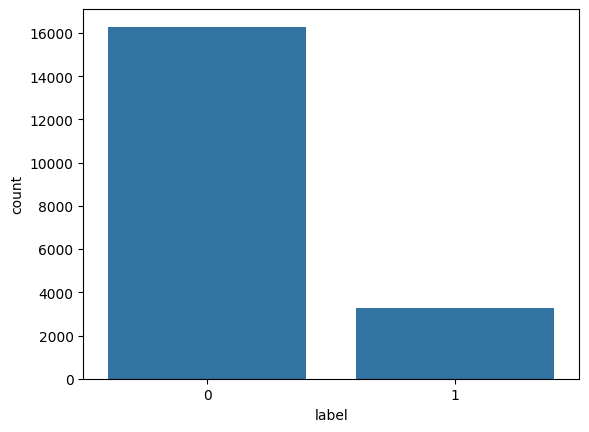

In [22]:
sns.countplot(x = 'label', data = df)

# Building Model

### Using deepmatcher

In [23]:
del df['id']

In [24]:
split_path = os.path.join('../', 'data')
# Split labeled data into train, valid, and test csv files to disk, with the split ratio of 3:1:1.
dm.data.split(df, split_path, 'train.csv', 'valid.csv', 'test.csv',[3, 1, 1])

In [25]:
train, validation, test = dm.data.process(
    path=split_path,
    cache='train_cache0.pth',
    train='train.csv',
    validation='valid.csv',
    test='test.csv',
    use_magellan_convention=True)

In [26]:
df.head()[['ltable_Full Name', 'rtable_Full Name', 'ltable_National Physician ID', 'rtable_National Physician ID', 'label']]

,ltable_Full Name,rtable_Full Name,ltable_National Physician ID,rtable_National Physician ID,label
248950,Christopher Walker,Manish Gupta,1306097613,1528250966,0
46846,Amirali Masoumi,Arthur Wang,1619293396,1184028367,0
39364,Michael Yochelson,Prashant Patel,1831188929,18210275251,0
67899,Rachel Rosovsky,Martin Austermann,1821072257,NaN,0
387752,Satish Maridaju Srinivas,Mazen AbuAwad,1801063482,1497739205,0


In [27]:
model = dm.MatchingModel(attr_summarizer='hybrid')
model.run_train(train, validation, epochs=3, batch_size=16, best_save_path=None, pos_neg_ratio=3)

/Users/tu/SourceCode/envs/env_3.8.16/lib/python3.8/site-packages/torch/nn/modules/module.py:949: UserWarning: Using non-full backward hooks on a Module that does not take as input a single Tensor or a tuple of Tensors is deprecated and will be removed in future versions. This hook will be missing some of the grad_input. Please use register_full_backward_hook to get the documented behavior.
  warnings.warn("Using non-full backward hooks on a Module that does not take as input a "
/Users/tu/SourceCode/envs/env_3.8.16/lib/python3.8/site-packages/torch/nn/modules/module.py:974: UserWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  warnings.warn("Using a non-full backward hook when the forward contains multiple autograd Nodes "


* Number of trainable parameters: 35333818
===>  TRAIN Epoch 1


/Users/tu/SourceCode/envs/env_3.8.16/lib/python3.8/site-packages/torch/nn/modules/module.py:939: UserWarning: Using non-full backward hooks on a Module that does not return a single Tensor or a tuple of Tensors is deprecated and will be removed in future versions. This hook will be missing some of the grad_output. Please use register_full_backward_hook to get the documented behavior.
  warnings.warn("Using non-full backward hooks on a Module that does not return a "
/Users/tu/SourceCode/envs/env_3.8.16/lib/python3.8/site-packages/torch/nn/functional.py:2741: UserWarning: reduction: 'mean' divides the total loss by both the batch size and the support size.'batchmean' divides only by the batch size, and aligns with the KL div math definition.'mean' will be changed to behave the same as 'batchmean' in the next major release.
  warnings.warn(


Finished Epoch 1 || Run Time:  472.8 | Load Time:    3.0 || F1:  99.23 | Prec:  99.28 | Rec:  99.18 || Ex/s:  24.65

===>  EVAL Epoch 1
Finished Epoch 1 || Run Time:   37.6 | Load Time:    1.0 || F1:  99.77 | Prec:  99.84 | Rec:  99.69 || Ex/s: 101.34

* Best F1: 99.76726144297905
---------------------

===>  TRAIN Epoch 2
Finished Epoch 2 || Run Time:  474.5 | Load Time:    3.0 || F1:  99.87 | Prec:  99.90 | Rec:  99.85 || Ex/s:  24.56

===>  EVAL Epoch 2
Finished Epoch 2 || Run Time:   37.2 | Load Time:    1.0 || F1:  99.84 | Prec:  99.84 | Rec:  99.84 || Ex/s: 102.32

* Best F1: 99.8449612403101
---------------------

===>  TRAIN Epoch 3
Finished Epoch 3 || Run Time:  461.1 | Load Time:    3.0 || F1:  99.87 | Prec:  99.90 | Rec:  99.85 || Ex/s:  25.27

===>  EVAL Epoch 3
Finished Epoch 3 || Run Time:   37.1 | Load Time:    1.0 || F1:  99.84 | Prec: 100.00 | Rec:  99.69 || Ex/s: 102.76

---------------------

Loading best model...
Training done.


99.8449612403101

In [28]:
model.run_eval(test)

===>  EVAL Epoch 3


Finished Epoch 3 || Run Time:   29.4 | Load Time:    0.9 || F1:  99.85 | Prec: 100.00 | Rec:  99.69 || Ex/s: 129.03



99.84686064318528

# Usecase

In [29]:
new_data_df = pd.read_csv("../data/test.csv")
new_data_df.head()

,ltable_Last Name,ltable_Status,ltable_National Physician ID,ltable_Full Name,ltable_Country,ltable_First Name,ltable_State/Region/Province,ltable_Specialty,ltable_Payment Currency,ltable_SAP Number,ltable_Payments Made To:,ltable_SAP Entity Name,ltable_HCP Category,ltable_Email Address,ltable_Contact Type,ltable_Quickbase Record ID#,rtable_Last Name,rtable_Status,rtable_National Physician ID,rtable_Full Name,rtable_Country,rtable_First Name,rtable_State/Region/Province,rtable_Specialty,rtable_Payment Currency,rtable_SAP Number,rtable_Payments Made To:,rtable_SAP Entity Name,rtable_HCP Category,rtable_Email Address,rtable_Contact Type,rtable_Quickbase Record ID#,label
0,Fraser,Active,NaN,Ashley Fraser,United States,Ashley,NaN,NaN,USD,NaN,NaN,NaN,Technician,Ashley.fraser@mylrh.org,HCP,2324.0,de Castro Afonso,Active,NaN,Luis Henrique de Castro Afonso,Brazil,Luis Henrique,Sao Paulo,Interventional Neuroradiology (INR),BRL,NaN,NaN,NaN,Physician,NaN,HCP,6047.0,0
1,el Hajjam,Active,NaN,Mostafa el Hajjam,France,Mostafa,NaN,Interventional Radiology (IR),EUR,90601338,Self,Mostafa El Hajjam,Physician,mostafa.elhajjam@aphp.fr,HCP,5591.0,el Hajjam,Active,NaN,Mostafa el Hajjam,France,Mostafa,NaN,Interventional Radiology (IR),EUR,90601338,Self,Mostafa El Hajjam,Physician,mostafa.elhajjam@aphp.fr,HCP,5591.0,1
2,Lewis,Active,NaN,Zachary Lewis,United States,Zachary,NaN,NaN,NaN,NaN,NaN,NaN,Technician,zachary.lewis@bswhealth.org,HCP,3164.0,Machi,Active,NaN,Paolo Machi,Switzerland,Paolo,NaN,NaN,EUR,NaN,NaN,NaN,Physician,NaN,HCP,775.0,0
3,Pietura,Active,NaN,Radoslaw Pietura,Poland,Radoslaw,NaN,NaN,EUR,NaN,NaN,NaN,Physician,radoslawpietura@poczta.onet.pl,HCP,3729.0,Caicedo,Active,NaN,Armando Jose Campo Caicedo,Colombia,Armando Jose Campo,NaN,Vascular Surgery (VS),USD,NaN,NaN,NaN,Physician,NaN,HCP,5947.0,0
4,Le Houerou,Active,NaN,Thomas Le Houerou,France,Thomas,NaN,Vascular Surgery (VS),EUR,90601189,Self,Thomas Le Houerou,Physician,thomas.lehouerou@yahoo.fr,HCP,6485.0,Le Houerou,Active,NaN,Thomas Le Houerou,France,Thomas,NaN,Vascular Surgery (VS),EUR,90601189,Self,Thomas Le Houerou,Physician,thomas.lehouerou@yahoo.fr,HCP,6485.0,1


In [30]:
new_data_df = new_data_df.reset_index(drop=True).reset_index().rename(columns = {"index": "_id"}).drop_duplicates()
new_data_df.to_csv("../data/new_data.csv", index=False)

In [47]:
candidate = dm.data.process_unlabeled(
    path=os.path.join('../', 'data', 'new_data.csv'),
    trained_model=model,
    ignore_columns=('ltable_id', 'rtable_id', 'label'))

In [48]:
predictions = model.run_prediction(candidate, output_attributes=list(candidate.get_raw_table().columns))
predictions = predictions.rename(columns={"match_score":"confident"})
threshold = 0.8
predictions['is_matched'] = np.where(predictions['confident'] > threshold, 1, 0)

===>  PREDICT Epoch 3


/Users/tu/SourceCode/envs/env_3.8.16/lib/python3.8/site-packages/torch/nn/modules/module.py:949: UserWarning: Using non-full backward hooks on a Module that does not take as input a single Tensor or a tuple of Tensors is deprecated and will be removed in future versions. This hook will be missing some of the grad_input. Please use register_full_backward_hook to get the documented behavior.
  warnings.warn("Using non-full backward hooks on a Module that does not take as input a "
/Users/tu/SourceCode/envs/env_3.8.16/lib/python3.8/site-packages/torch/nn/modules/module.py:974: UserWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  warnings.warn("Using a non-full backward hook when the forward contains multiple autograd Nodes "
/Users/tu/SourceCode/envs/env_3.8.16/lib/python3.8/site-p

Finished Epoch 3 || Run Time:   28.5 | Load Time:    0.9 || F1:   0.00 | Prec:   0.00 | Rec:   0.00 || Ex/s:   0.00



In [50]:
predictions[['ltable_First Name', 'ltable_Last Name', 'rtable_First Name', 'rtable_Last Name', 'ltable_Full Name', 'rtable_Full Name',  'confident', 'is_matched']].head()

,ltable_First Name,ltable_Last Name,rtable_First Name,rtable_Last Name,ltable_Full Name,rtable_Full Name,confident,is_matched
_id,,,,,,,,
0,Ashley,Fraser,Luis Henrique,de Castro Afonso,Ashley Fraser,Luis Henrique de Castro Afonso,0.130752,0
1,Mostafa,el Hajja,Mostafa,el Hajjam,Mostafa el Hajjam,Mostafa el Hajjam,0.981638,1
2,Zachary,Lewis,Paolo,Machi,Zachary Lewis,Paolo Machi,0.136102,0
3,Radoslaw,Pietura,Armando Jose Campo,Caicedo,Radoslaw Pietura,Armando Jose Campo Caicedo,0.134011,0
4,Thomas,Le Houerou,Thomas,Le Houerou,Thomas Le Houerou,Thomas Le Houerou,0.981994,1


In [43]:
predictions.query("(is_matched == 1) ")[['ltable_First Name', 'ltable_Last Name', 'rtable_First Name', 'rtable_Last Name', 'ltable_Full Name', 'rtable_Full Name',  'confident', 'is_matched']].head(20)

,ltable_First Name,ltable_Last Name,rtable_First Name,rtable_Last Name,ltable_Full Name,rtable_Full Name,confident,is_matched
_id,,,,,,,,
1,Mostafa,el Hajjam,Mostafa,el Hajjam,Mostafa el Hajjam,Mostafa el Hajjam,0.982001,1
4,Thomas,Le Houerou,Thomas,Le Houerou,Thomas Le Houerou,Thomas Le Houerou,0.982120,1
6,Saleem,Husain,Saleem,Husain,Saleem Husain,Saleem Husain,0.982729,1
10,Roger,Alvarez,Roger,Alvarez,Roger Alvarez,Roger Alvarez,0.984103,1
16,Shawana,Hussain,Shawana,Hussain,Shawana Hussain,Shawana Hussain,0.982748,1
23,Hector Alfredo,Montenegro Rosales,Hector Alfredo,Montenegro Rosales,Hector Alfredo Montenegro Rosales,Hector Alfredo Montenegro Rosales,0.980793,1
25,Hiroyuki,Tajima,Hiroyuki,Tajima,Hiroyuki Tajima,Hiroyuki Tajima,0.982575,1
32,Ian,McCafferty,Ian,McCafferty,Ian McCafferty,Ian McCafferty,0.983410,1
33,Maurizio,Resta,Maurizio,Resta,Maurizio Resta,Maurizio Resta,0.982909,1


In [54]:
candidate = dm.data.process_unlabeled(
    path=os.path.join('../', 'data', 'new_data2.csv'),
    trained_model=model,
    ignore_columns=('ltable_id', 'rtable_id', 'label'))

In [55]:
predictions = model.run_prediction(candidate, output_attributes=list(candidate.get_raw_table().columns))
predictions = predictions.rename(columns={"match_score":"confident"})
threshold = 0.8
predictions['is_matched'] = np.where(predictions['confident'] > threshold, 1, 0)

===>  PREDICT Epoch 3


/Users/tu/SourceCode/envs/env_3.8.16/lib/python3.8/site-packages/torch/nn/modules/module.py:949: UserWarning: Using non-full backward hooks on a Module that does not take as input a single Tensor or a tuple of Tensors is deprecated and will be removed in future versions. This hook will be missing some of the grad_input. Please use register_full_backward_hook to get the documented behavior.
  warnings.warn("Using non-full backward hooks on a Module that does not take as input a "
/Users/tu/SourceCode/envs/env_3.8.16/lib/python3.8/site-packages/torch/nn/modules/module.py:974: UserWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  warnings.warn("Using a non-full backward hook when the forward contains multiple autograd Nodes "
/Users/tu/SourceCode/envs/env_3.8.16/lib/python3.8/site-p

Finished Epoch 3 || Run Time:   29.4 | Load Time:    0.9 || F1:   0.00 | Prec:   0.00 | Rec:   0.00 || Ex/s:   0.00



In [57]:
predictions.query("(is_matched == 1) ")[['ltable_First Name', 'ltable_Last Name', 'rtable_First Name', 'rtable_Last Name', 'ltable_Full Name', 'rtable_Full Name',  'confident', 'is_matched']].head(20)

,ltable_First Name,ltable_Last Name,rtable_First Name,rtable_Last Name,ltable_Full Name,rtable_Full Name,confident,is_matched
_id,,,,,,,,
1,Mostafa,el Hajja,Mostafa,el Hajjam,Mostafa el Hajja,Mostafa el Hajjam,0.981267,1
4,Thomas,Le Houerou,Thomas,Le Houerou,Thomas Le Houerou,Thomas Le Houerou,0.981994,1
6,Salem,Husain,Saleem,Husain,Salem Husain,Saleem Husain,0.962436,1
10,Roger,Alvarez,Roger,Alvarez,Roger Alvarez,Roger Alvarez,0.984024,1
16,Shawana,Hussain,Shawana,Hussain,Shawana Hussain,Shawana Hussain,0.982657,1
23,Hector Alfredo,Montenegro Rosales,Hector Alfredo,Montenegro Rosales,Hector Alfredo Montenegro Rosales,Hector Alfredo Montenegro Rosales,0.980623,1
25,Hiroyuki,Tajima,Hiroyuki,Tajima,Hiroyuki Tajima,Hiroyuki Tajima,0.981998,1
32,Ian,McCafferty,Ian,McCafferty,Ian McCafferty,Ian McCafferty,0.983032,1
33,Maurizio,Resta,Maurizio,Resta,Maurizio Resta,Maurizio Resta,0.982348,1
